In [1]:
# Cell 1 – Imports & configuration

import pandas as pd
import numpy as np

from scipy.spatial.distance import pdist
from scipy.stats import entropy

import warnings
warnings.filterwarnings('ignore')

# Paths – adjust if needed
INPUT_FILE  = r"D:\emotion-drift-project\data\eyet4empathy_clean.csv"
OUTPUT_FILE = r"D:\emotion-drift-project\data\eyet4empathy_features.csv"

print("Feature engineering notebook ready")
print("Input :", INPUT_FILE)
print("Output:", OUTPUT_FILE)

Feature engineering notebook ready
Input : D:\emotion-drift-project\data\eyet4empathy_clean.csv
Output: D:\emotion-drift-project\data\eyet4empathy_features.csv


In [2]:
# Cell 2 – Load cleaned data

print("Loading cleaned eye-tracking samples...")

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False,
    dtype={
        'Participant name': 'category',
        'Recording name':   'category',
        'Eye movement type': 'category'
    }
)

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("Columns present:", df.columns.tolist()[:15], "...")

# Quick check of grouping keys
print("\nUnique participants:", df['Participant name'].nunique())
print("Unique recordings:",  df['Recording name'].nunique())

Loading cleaned eye-tracking samples...
Loaded: 3,588,494 rows × 16 columns
Columns present: ['Participant name', 'Recording name', 'Recording timestamp', 'Presented Stimulus name', 'Presented Media name', 'Eye movement type', 'Gaze event duration', 'Gaze point X final', 'Gaze point Y final', 'Fixation point X', 'Fixation point Y', 'Validity left', 'Validity right', 'Gaze point X', 'Gaze point Y'] ...

Unique participants: 60
Unique recordings: 48


In [3]:
df.shape

(3588494, 16)

In [4]:
# Cell 3 – Group by trial

print("Grouping by participant & recording...")

grouped = df.groupby(
    ['Participant name', 'Recording name'],
    observed=True,
    sort=False
)

print(f"→ Number of trials: {len(grouped):,}")

Grouping by participant & recording...
→ Number of trials: 358


In [5]:
# Cell 4 – Helper functions for features

def fixation_count(x):
    return (x == 'Fixation').sum()

def saccade_count(x):
    return (x == 'Saccade').sum()

def blink_count(x):
    return (x == 'Blink').sum() if 'Blink' in x.values else 0

def mean_fix_duration(g):
    fix = g[g['Eye movement type'] == 'Fixation']
    return fix['Gaze event duration'].mean() if len(fix) > 0 else np.nan

def mean_sacc_duration(g):
    sac = g[g['Eye movement type'] == 'Saccade']
    return sac['Gaze event duration'].mean() if len(sac) > 0 else np.nan

def mean_sacc_amplitude(g):
    sac = g[g['Eye movement type'] == 'Saccade']
    if len(sac) < 2:
        return np.nan
    coords = sac[['Gaze point X final', 'Gaze point Y final']].dropna()
    if len(coords) < 2:
        return np.nan
    return pdist(coords).mean()

def gaze_dispersion(g):
    coords = g[['Gaze point X final', 'Gaze point Y final']].dropna()
    if len(coords) < 3:
        return np.nan
    return pdist(coords).mean()

def gaze_spread_x(g):
    return g['Gaze point X final'].std()

def gaze_spread_y(g):
    return g['Gaze point Y final'].std()



def gaze_entropy_2d(g, bins=20):
    coords = g[['Gaze point X final', 'Gaze point Y final']].dropna()
    if len(coords) < 30:
        return np.nan
    hist, _, _ = np.histogram2d(
        coords['Gaze point X final'],
        coords['Gaze point Y final'],
        bins=bins
    )
    hist = hist / hist.sum()
    return entropy(hist.flatten() + 1e-10)

print("Feature functions defined.")

Feature functions defined.


In [6]:
# Cell 5 – Safe features (only using available columns)

print("Extracting safe features...")

agg_dict = {
    'Gaze point X final': ['mean', 'std', 'min', 'max'],
    'Gaze point Y final': ['mean', 'std', 'min', 'max'],
    'Gaze event duration': ['mean', 'sum', 'std', 'min', 'max'],
    'Fixation point X': ['mean', 'std', 'min', 'max'],
    'Fixation point Y': ['mean', 'std', 'min', 'max'],
}

features = grouped.agg(agg_dict)

# Flatten columns
features.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col 
                    for col in features.columns.values]

# Add dispersion & entropy (safe)
features['gaze_dispersion_mean'] = grouped.apply(gaze_dispersion)
features['gaze_entropy_2d']      = grouped.apply(gaze_entropy_2d)

features = features.reset_index()

print(f"Shape: {features.shape}")
print(features.head(5))

Extracting safe features...
Shape: (358, 25)
  Participant name Recording name  Gaze point X final_mean  \
0  Participant0001     Recording1              1014.454319   
1  Participant0001     Recording2               972.758945   
2  Participant0001     Recording3               950.517751   
3  Participant0001     Recording4               964.825252   
4  Participant0001     Recording5               992.469686   

   Gaze point X final_std  Gaze point X final_min  Gaze point X final_max  \
0              293.315931                   280.0                  1610.0   
1              308.790919                   328.0                  1679.0   
2              272.389286                   182.0                  1595.0   
3              229.814273                   322.0                  1763.0   
4              316.109465                   353.0                  2000.0   

   Gaze point Y final_mean  Gaze point Y final_std  Gaze point Y final_min  \
0               261.575620              2

=== Feature Exploration ===

Feature statistics (top 10 most variable):
                                mean         std       min          max
Gaze event duration_sum   2654227.28  3477194.64  88783.00  54859846.00
Gaze event duration_max      1571.48     1361.66    192.00     14283.00
Gaze event duration_std       344.09      421.16     25.82      5134.90
Fixation point X_max         1577.66      265.86    834.00      2298.00
Gaze event duration_mean      269.97      249.59     18.90      3245.84
Gaze point X final_max       1761.19      209.77   1274.00      2000.00
Fixation point Y_max          967.83      152.96    550.00      2055.00
Fixation point Y_min           -7.45      141.33   -214.00       509.00
Gaze point X final_min        195.21      134.98      0.00       739.00
Fixation point X_min          336.28      133.70   -289.00      1070.00


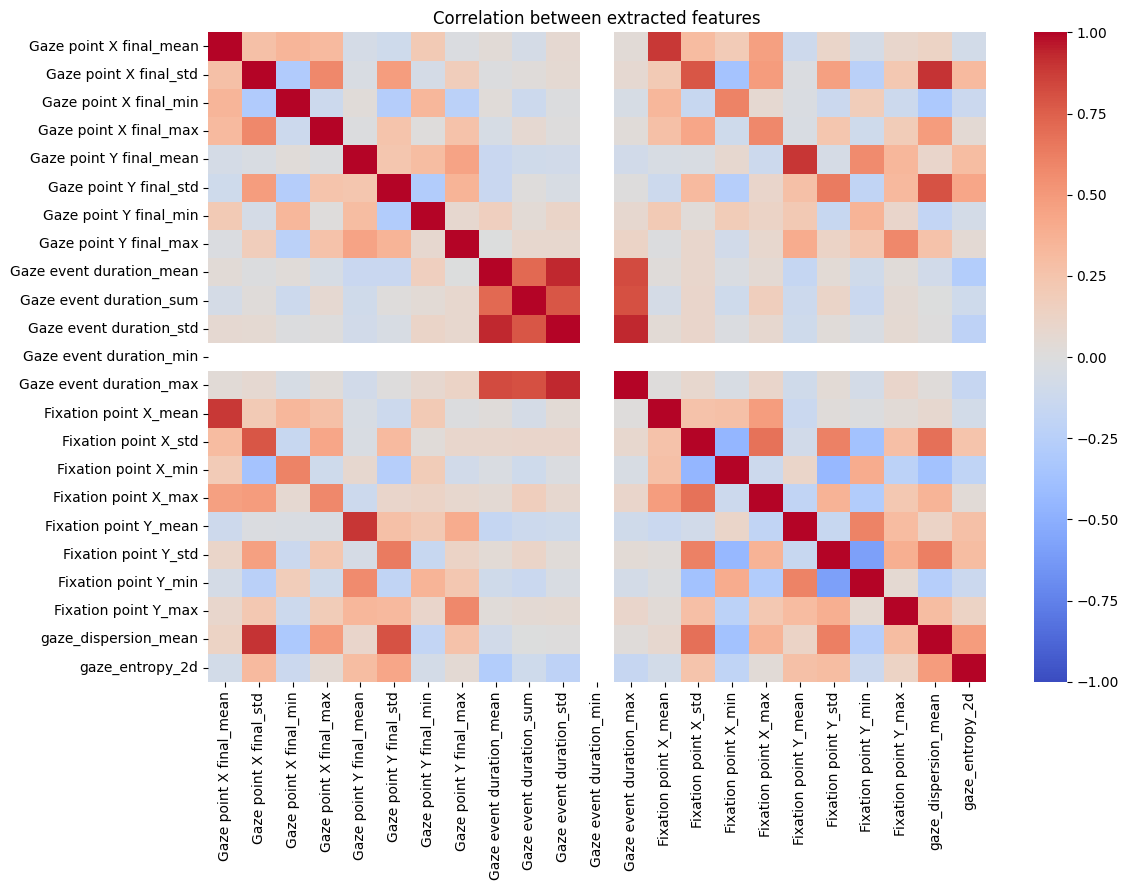

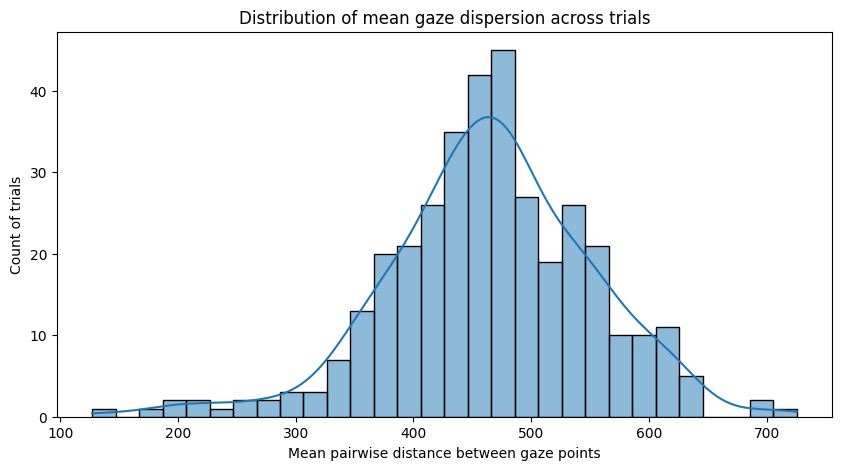

In [7]:
# Cell 7 – Quick exploration & visualization of features

import matplotlib.pyplot as plt
import seaborn as sns

print("=== Feature Exploration ===\n")

# Basic statistics
print("Feature statistics (top 10 most variable):")
print(features.describe().T.sort_values('std', ascending=False).head(10)[['mean','std','min','max']].round(2))

# Correlation heatmap (only numeric columns)
numeric_cols = features.select_dtypes(include=np.number).columns
corr = features[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title("Correlation between extracted features")
plt.tight_layout()
plt.show()

# Example: Distribution of gaze dispersion
plt.figure(figsize=(10, 5))
sns.histplot(features['gaze_dispersion_mean'], kde=True, bins=30)
plt.title("Distribution of mean gaze dispersion across trials")
plt.xlabel("Mean pairwise distance between gaze points")
plt.ylabel("Count of trials")
plt.show()

In [8]:
# Cell 8 – Create gaze behavior labels (Fixation Duration Based)

print("Creating gaze behavior labels using fixation duration thresholds...\n")

# Literature-based fixation duration thresholds:
# < 200 ms  → Exploratory (rapid shifting)
# 200–300 ms → Moderate
# > 300 ms → Focused / sustained attention

def get_label(row):
    duration = row['Gaze event duration_mean']
    
    if pd.isna(duration):
        return np.nan
    
    if duration < 200:
        return 'High'      # High exploration
    elif duration <= 300:
        return 'Moderate'
    else:
        return 'Low'       # Low exploration (more focused)

features['gaze_behavior_level'] = features.apply(get_label, axis=1)

# Show distribution
print("Label distribution:")
print(
    features['gaze_behavior_level']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .astype(str) + " %"
)

# Preview
print("\nSample with labels:")
print(features[['Participant name',
                'Recording name',
                'Gaze event duration_mean',
                'gaze_behavior_level']].head(10))

Creating gaze behavior labels using fixation duration thresholds...

Label distribution:
gaze_behavior_level
High        41.9 %
Moderate    31.8 %
Low         26.3 %
Name: proportion, dtype: str

Sample with labels:
  Participant name Recording name  Gaze event duration_mean  \
0  Participant0001     Recording1                152.218885   
1  Participant0001     Recording2                147.151248   
2  Participant0001     Recording3                131.871441   
3  Participant0001     Recording4                139.975036   
4  Participant0001     Recording5                150.404402   
5  Participant0001     Recording6                160.502705   
6  Participant0001     Recording7                240.841064   
7  Participant0001     Recording8                167.529620   
8  Participant0002     Recording1                179.536756   
9  Participant0002     Recording2                172.522181   

  gaze_behavior_level  
0                High  
1                High  
2                H

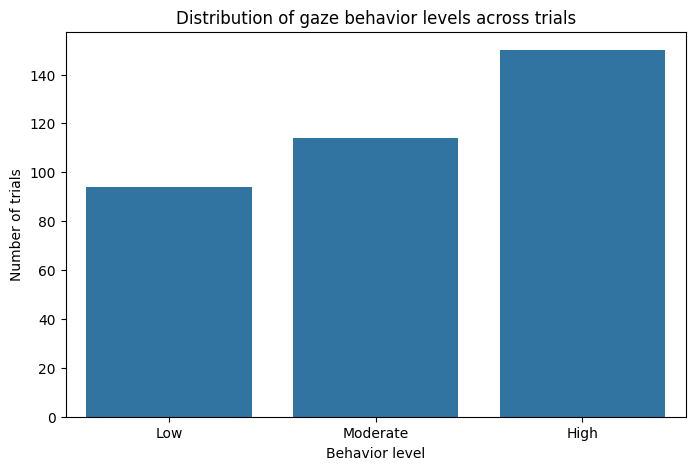


Final labeled dataset saved to:
D:\emotion-drift-project\data\eyet4empathy_features_labeled.csv
Rows: 358
Columns: 26


In [9]:
# Cell 9 – Visualize labels & save final table

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=features,
              x='gaze_behavior_level',
              order=['Low', 'Moderate', 'High'])

plt.title("Distribution of gaze behavior levels across trials")
plt.xlabel("Behavior level")
plt.ylabel("Number of trials")
plt.show()

# Save final dataset
final_output = r"D:\emotion-drift-project\data\eyet4empathy_features_labeled.csv"
features.to_csv(final_output, index=False)

print(f"\nFinal labeled dataset saved to:")
print(final_output)
print(f"Rows: {len(features)}")
print(f"Columns: {len(features.columns)}")